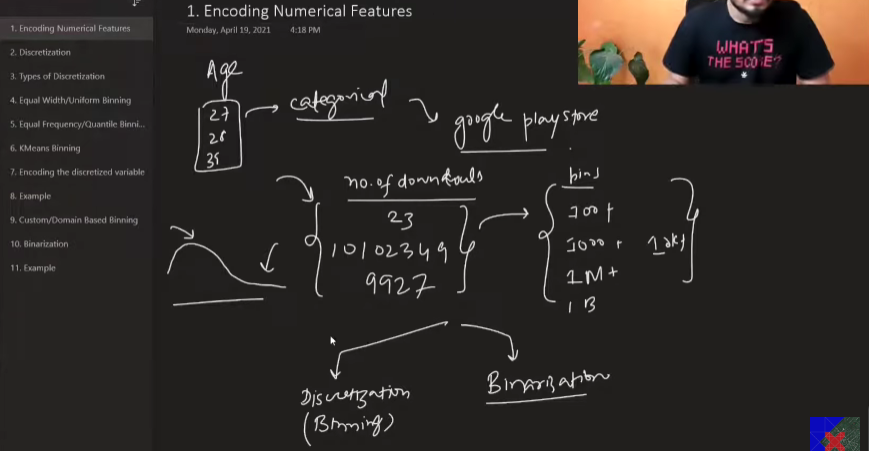

### Numerical data are good then why do we need to encode them?

- Depends, for example in the pic, a google dataset had no. of downloads for playstore, so some had quite large values, and some had small values

- so if we make bins according to the no. of downloads, it might me more useful for the model to learn

# Two types of encoding for numerical features
1. Binning (Discretization): It is the process of converting numerical features into categorical features by creating bins. For example, if we have a feature called "age" which has values from 0 to 100, we can create bins like "0-10", "11-20", "21-30", etc. and assign a category to each bin.
2. Binarization: It is the process of converting numerical features into binary features. For example, if we have a feature called "age" which has values from 0 to 100, we can create a binary feature called "age>30" which will have values 0 and 1, where 1 indicates that the age is greater than 30 and 0 indicates that the age is less than or equal to 30.

# Binning

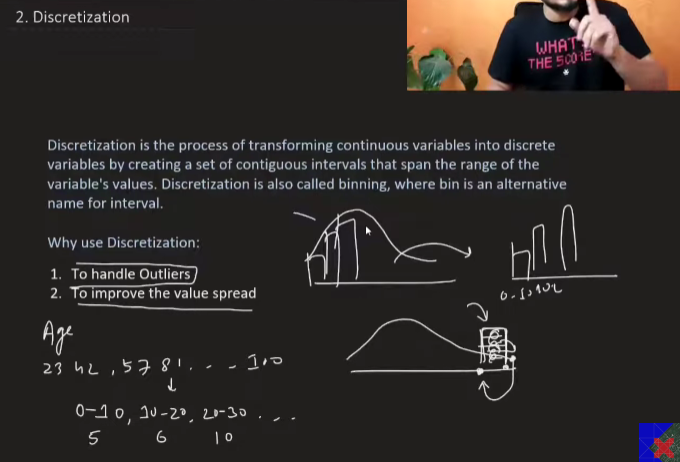

### Why use discretization?
- **handle outliers**: for example if we have a feature called "age" which has values from 0 to 100, and we have some outliers like 150, 200, etc. then we can create bins like "0-10", "11-20", "21-30", etc. and assign a category to each bin, so the outliers will be in the last bin and it will not affect the model much.

- **Improve the spread of data**: if for some values of age we have so many data points then we can spread the portion

# Types of binning
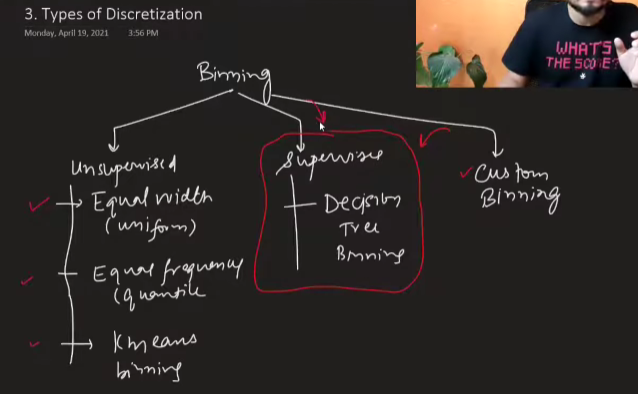

- in this lesson we will skip supeervised binning as we need knowledge of desicion tree for that (we will cover it in the future or see from otheqr sources)

## 1.  Equal width binning

- Decide the number of bins you want to create
- Find the min and max values of the feature
- Calculate the width of each bin using the formula: width = (max - min) / number of bins (Equal width binning)

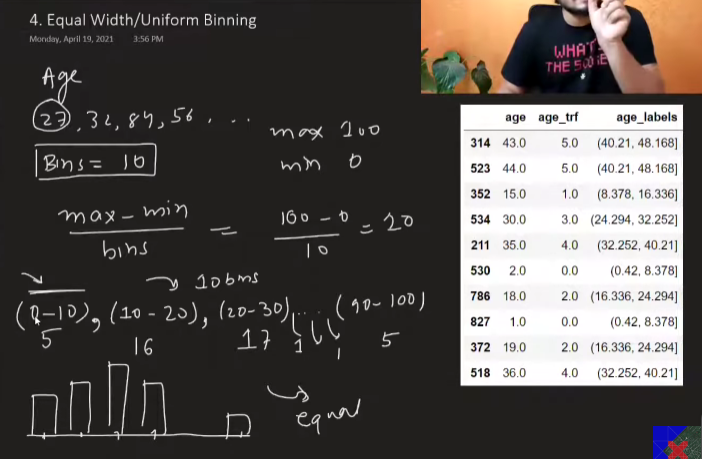

### Properties of equal width binning
- Handles outliers
- There is no change in spread of data, histogram will be same as before, so it will not affect the model much

## 2. Equal frequency binning (Quantile binning)

- Decide the number of bins you want to create
- Each bin will have the percentile of the data as the number of bins
- For example , no. of bins = 10, then each bin will have 10 percentiles of the data

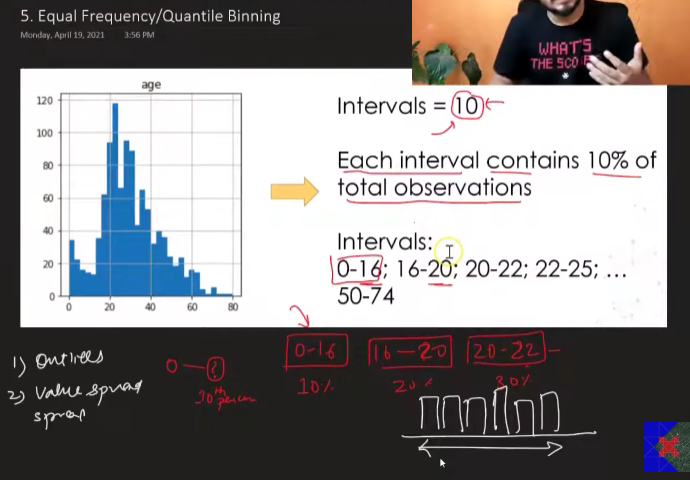

### Properties of equal frequency binning
- Handles outliers
- It spreads out the data, so histogram will be more uniform


## 3. K-means binning

- It is used when data humara clusters mei faila ho, like kuch door mei kuch logo ka age hai, then baaki logo ka kuch or door

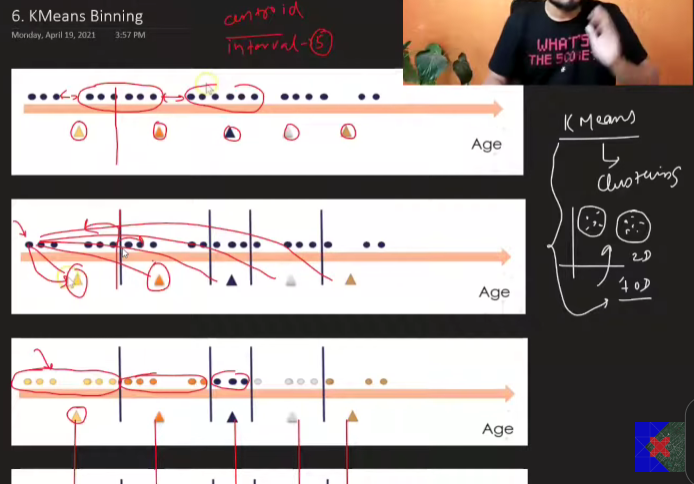

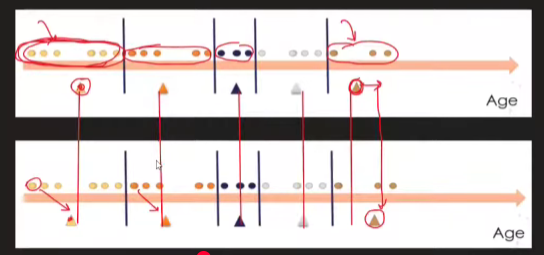

- Decide the no. of bins/intervals/centroids you want to create
- Place the centroids at regular intervals along the range of the data
- Assign each data point to the nearest centroid, forming clusters according the line drawn between the centroids
- Then shift the centroids to the mean of the data points assigned to them
- Repeat the process until the centroids do not change significantly

# Encoding using sklearn

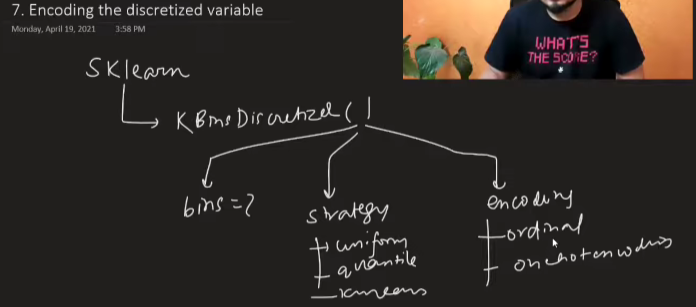
- We can use KBinsDiscretizer from sklearn to perform binning
- We can specify the number of bins, the strategy (equal width, equal frequency, k-means) and the encoding (ordinal, onehot)
- encoding refers to like if there is any comparison between the bins, then we can use ordinal encoding, if there is no comparison between the bins, then we can use onehot encoding

In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer

In [3]:
df = pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])

In [4]:
df.dropna(inplace=True)

In [5]:
df.shape

(714, 3)

In [6]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [7]:
X = df.iloc[:,1:]
y = df.iloc[:,0]

In [8]:

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [9]:
X_train.head(2)

,Age,Fare
328,31.0,20.5250
73,26.0,14.4542


In [10]:

clf = DecisionTreeClassifier()

In [11]:
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)

In [12]:

accuracy_score(y_test,y_pred)

0.6153846153846154

In [13]:
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

np.float64(0.6274647887323943)

In [14]:
kbin_age = KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='quantile')
kbin_fare = KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='quantile')

In [15]:
trf = ColumnTransformer([
    ('first',kbin_age,[0]),
    ('second',kbin_fare,[1])
])

In [16]:
X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.transform(X_test)

c:\Users\Kaushik Mandal\.virtualenvs\ClassicalML-_wR1sNSC\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
c:\Users\Kaushik Mandal\.virtualenvs\ClassicalML-_wR1sNSC\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


In [18]:
trf.named_transformers_['first'].n_bins_ # no. of bins for age

array([15])

In [ ]:
trf.named_transformers_['first'].bin_edges_ # range of bins for age

array([array([ 0.42,  6.  , 16.  , 19.  , 21.  , 23.  , 25.  , 28.  , 30.  ,
              32.  , 35.  , 38.  , 42.  , 47.  , 54.  , 80.  ])             ],
      dtype=object)

In [19]:
trf.named_transformers_['first'].bin_edges_

array([array([ 0.42,  6.  , 16.  , 19.  , 21.  , 23.  , 25.  , 28.  , 30.  ,
              32.  , 35.  , 38.  , 42.  , 47.  , 54.  , 80.  ])             ],
      dtype=object)

In [20]:
output = pd.DataFrame({
    'age':X_train['Age'],
    'age_trf':X_train_trf[:,0],
    'fare':X_train['Fare'],
    'fare_trf':X_train_trf[:,1]
})

In [21]:
output['age_labels'] = pd.cut(x=X_train['Age'],
                                    bins=trf.named_transformers_['first'].bin_edges_[0].tolist())
output['fare_labels'] = pd.cut(x=X_train['Fare'],
                                    bins=trf.named_transformers_['second'].bin_edges_[0].tolist())



In [22]:
output.sample(5)

,age,age_trf,fare,fare_trf,age_labels,fare_labels
488,30.0,8.0,8.0500,3.0,"(28.0, 30.0]","(7.896, 8.158]"
555,62.0,14.0,26.5500,10.0,"(54.0, 80.0]","(26.0, 26.55]"
294,24.0,5.0,7.8958,3.0,"(23.0, 25.0]","(7.775, 7.896]"
333,16.0,2.0,18.0000,7.0,"(6.0, 16.0]","(14.454, 18.75]"
221,27.0,6.0,13.0000,6.0,"(25.0, 28.0]","(10.5, 13.0]"


In [23]:
clf = DecisionTreeClassifier()
clf.fit(X_train_trf,y_train)
y_pred2 = clf.predict(X_test_trf)

In [24]:
accuracy_score(y_test,y_pred2)

0.6363636363636364

In [25]:
X_trf = trf.fit_transform(X)
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

c:\Users\Kaushik Mandal\.virtualenvs\ClassicalML-_wR1sNSC\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
c:\Users\Kaushik Mandal\.virtualenvs\ClassicalML-_wR1sNSC\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


np.float64(0.6317097026604068)

In [26]:
def discretize(bins,strategy):
    kbin_age = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    kbin_fare = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    
    trf = ColumnTransformer([
        ('first',kbin_age,[0]),
        ('second',kbin_fare,[1])
    ])
    
    X_trf = trf.fit_transform(X)
    print(np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy')))
    
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Age'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:,0],color='red')
    plt.title("After")

    plt.show()
    
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Fare'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:,1],color='red')
    plt.title("Fare")

    plt.show()
    

0.640121283255086


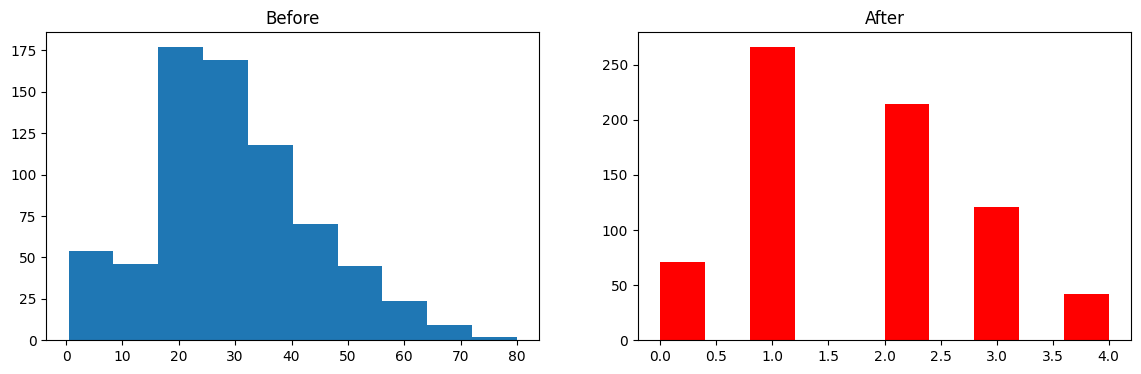

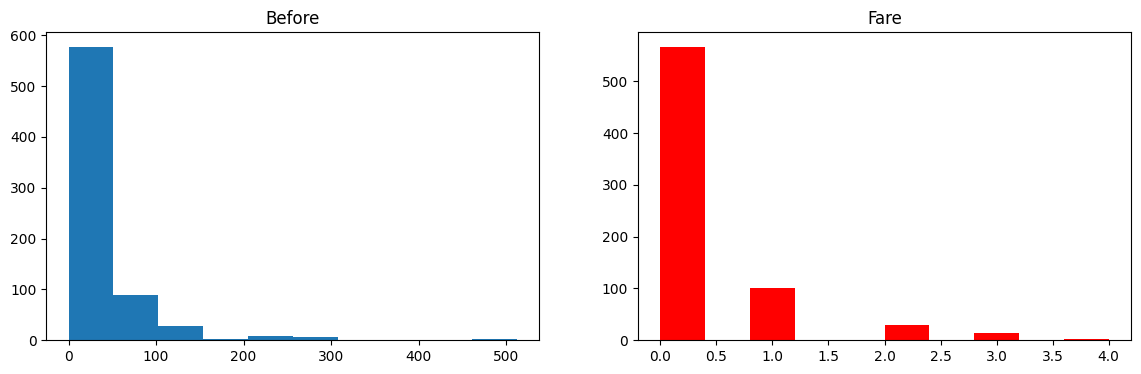

In [27]:
discretize(5,'kmeans')

# Custom binning
- We can also create our own bins using pd.cut() or pd.qcut() functions from pandas based on our domain knowledge or based on the distribution of the data

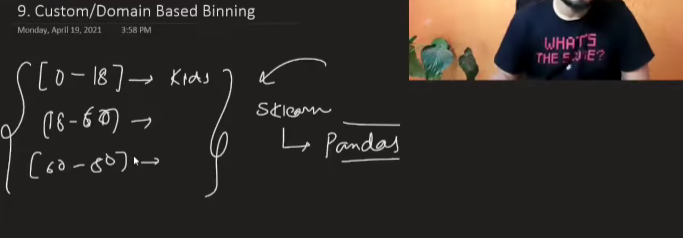